In [7]:
import pandas as pd
import numpy as np

df = pd.read_csv('/home/mario/251212-MINT-DEMO/Local/workspaces/027729e0-a68c-4034-8552-8f0d29fdc8bb/results/results_backup.csv')

LRG = [
    'HILIC5_Neg_178878M0098_1_P1',
    'HILIC5_Neg_178878M0098_2_P1',
    'HILIC5_Neg_178878M0098_3_P1',
    'HILIC5_Neg_186191M0001_1_P2',
    'HILIC5_Neg_186191M0001_2_P2',
    'HILIC5_Neg_186191M0001_3_P2',
    'HILIC5_Neg_186191M0010_1_P2',
    'HILIC5_Neg_186191M0010_2_P2',
    'HILIC5_Neg_186191M0010_3_P2',
    'HILIC5_Neg_186191M0019_1_P3',
    'HILIC5_Neg_186191M0019_2_P3',
    'HILIC5_Neg_186191M0019_3_P3',
    'HILIC5_Neg_186191M0025_1_P4',
    'HILIC5_Neg_186191M0025_2_P4',
    'HILIC5_Neg_186191M0025_3_P4',
    'HILIC5_Neg_186191M0030_1_P3',
    'HILIC5_Neg_186191M0030_2_P3',
    'HILIC5_Neg_186191M0030_3_P3',
    'HILIC5_Neg_191348M0007_1_P1'
    ]

df['label'] = df['ms_file_label'].apply(lambda x: 'LRG' if x in LRG else 'Customer')

df['peak_area_top3_log'] = np.log1p(df['peak_area_top3'])

import ast
import numpy as np

def safe_eval(x):
    try:
        return ast.literal_eval(x)
    except:
        return np.nan

df['scan_time'] = df['scan_time'].apply(safe_eval)

df.head()

,peak_label,ms_file_label,total_intensity,peak_area,peak_area_top3,peak_max,peak_min,peak_mean,peak_rt_of_max,peak_median,...,peak_mz_of_max,peak_area_fitted,peak_sigma,peak_tau,peak_asymmetry,peak_rt_fitted,fit_r_squared,fit_success,label,peak_area_top3_log
0,Thymine,HILIC5_Neg_190379M0034_2,NaN,7452.0,8596.0,8595.0,1.0,406.0,40.2840,1.0,...,125.035683,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Customer,9.059169
1,Thymine,HILIC5_Neg_192099M0003_2,NaN,22623.0,8533.0,8532.0,1.0,1041.0,40.2843,1.0,...,125.035530,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Customer,9.051813
2,Thymine,HILIC5_Neg_192099M0093_2,NaN,23.0,2.0,1.0,1.0,1.0,40.2820,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Customer,1.098612
3,Tryptophan,HILIC5_Neg_190379M0032_2,NaN,269555.0,479226.0,287389.0,1.0,11295.0,124.8410,1.0,...,203.082626,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Customer,13.079930
4,Tryptophan,HILIC5_Neg_196297M0027_1_20260412060811,NaN,359174.0,620309.0,365789.0,1.0,15055.0,124.3240,1.0,...,203.082657,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Customer,13.337975


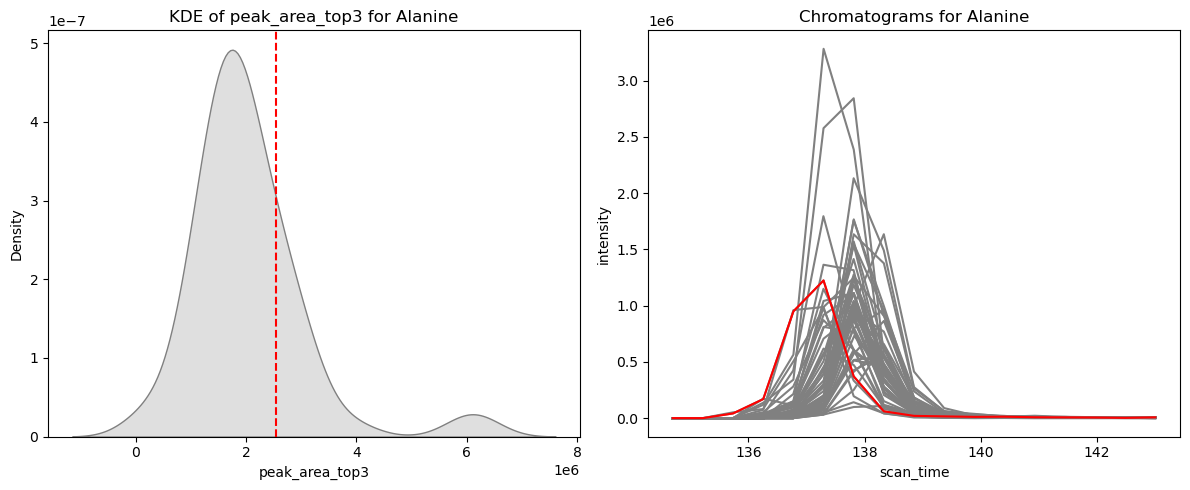

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

compound = 'Alanine'
sample = 'HILIC5_Neg_196297M0027_1_20260412060811'

sns.kdeplot(data=df[df['peak_label'] == compound], x='peak_area_top3', ax=axs[0], fill=True, 
            color='gray')

# add a vertical line for the specific compound/sample
axs[0].axvline(df[(df['peak_label'] == compound) & 
                  (df['ms_file_label'] == sample)]
                  ['peak_area_top3']
                  .values[0], 
                  color='red', 
                  linestyle='--')


axs[0].set_title(f'KDE of peak_area_top3 for {compound}')

import ast

sub = df[df['peak_label'] == compound].copy()

def to_list(x):
    if isinstance(x, str):
        return ast.literal_eval(x)
    return x

sub['scan_time'] = sub['scan_time'].apply(to_list)
sub['intensity'] = sub['intensity'].apply(to_list)

rows = []
for _, row in sub.iterrows():
    st = row['scan_time']
    inten = row['intensity']
    
    if not isinstance(st, (list, tuple, np.ndarray, pd.Series)):
        continue
    if not isinstance(inten, (list, tuple, np.ndarray, pd.Series)):
        continue

    for t, y in zip(st, inten):   # keeps only matched pairs up to shortest length
        new_row = row.copy()
        new_row['scan_time'] = t
        new_row['intensity'] = y
        rows.append(new_row)

exploded = pd.DataFrame(rows)
exploded['scan_time'] = pd.to_numeric(exploded['scan_time'], errors='coerce')
exploded['intensity'] = pd.to_numeric(exploded['intensity'], errors='coerce')

exploded[['ms_file_label', 'scan_time', 'intensity']] 



sns.lineplot(data=exploded,
             x='scan_time',
             y='intensity',
             hue='ms_file_label',
             legend=False,
             estimator=None,
             palette=['gray'] * exploded['ms_file_label'].nunique(),
             ax=axs[1]
             )

sns.lineplot(data=exploded[exploded['ms_file_label'] == sample],
             x='scan_time',
             y='intensity',
             color='red',
             estimator=None,
             ax=axs[1]
             )

axs[1].set_title(f'Chromatograms for {compound}')

# axs[1].set_yscale('log')

plt.tight_layout()
plt.show()

In [60]:
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display, clear_output

# -----------------------------
# Styling
# -----------------------------
sns.set_theme(style="white", context="notebook")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#fbfbfc",
    "axes.edgecolor": "#d9dbe1",
    "axes.linewidth": 1.0,
    "grid.color": "#e9ebf0",
    "grid.linewidth": 0.8,
    "axes.titlesize": 13,
    "axes.titleweight": "semibold",
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "font.family": "sans-serif",
})

# -----------------------------
# Helpers
# -----------------------------
def to_list(x):
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except Exception:
            return np.nan
    return x

def get_samples(df, peak_label):
    return sorted(
        df.loc[df["peak_label"] == peak_label, "ms_file_label"]
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    )

def build_exploded(df, compound):
    sub = df[df["peak_label"] == compound].copy()
    if sub.empty:
        return pd.DataFrame(columns=["ms_file_label", "scan_time", "intensity"])

    sub["scan_time"] = sub["scan_time"].apply(to_list)
    sub["intensity"] = sub["intensity"].apply(to_list)

    rows = []
    for _, row in sub.iterrows():
        st = row["scan_time"]
        inten = row["intensity"]

        if not isinstance(st, (list, tuple, np.ndarray, pd.Series)):
            continue
        if not isinstance(inten, (list, tuple, np.ndarray, pd.Series)):
            continue

        for t, y in zip(st, inten):
            rows.append({
                "ms_file_label": str(row["ms_file_label"]),
                "scan_time": t,
                "intensity": y,
            })

    exploded = pd.DataFrame(rows)
    if exploded.empty:
        return pd.DataFrame(columns=["ms_file_label", "scan_time", "intensity"])

    exploded["scan_time"] = pd.to_numeric(exploded["scan_time"], errors="coerce")
    exploded["intensity"] = pd.to_numeric(exploded["intensity"], errors="coerce")
    exploded = exploded.dropna(subset=["ms_file_label", "scan_time", "intensity"])
    return exploded.sort_values(["ms_file_label", "scan_time"])

def choose_scale(values):
    values = pd.to_numeric(values, errors="coerce").dropna()
    if values.empty:
        return 1, ""
    vmax = values.abs().max()
    if vmax >= 1e9:
        return 1e9, r"$\times 10^9$"
    elif vmax >= 1e6:
        return 1e6, r"$\times 10^6$"
    elif vmax >= 1e3:
        return 1e3, r"$\times 10^3$"
    return 1, ""

# -----------------------------
# Widgets
# -----------------------------
compound_options = sorted(df["peak_label"].dropna().astype(str).unique().tolist())

compound_dd = widgets.Dropdown(
    options=compound_options,
    value=compound_options[0] if compound_options else None,
    description="Compound",
    style={"description_width": "80px"},
    layout=widgets.Layout(width="320px", margin="0 18px 0 0"),
)

sample_dd = widgets.SelectMultiple(
    options=[],
    description="Samples",
    style={"description_width": "80px"},
    layout=widgets.Layout(width="430px", height="120px"),
)

output = widgets.Output(layout=widgets.Layout(border="1px solid #e5e7eb", padding="16px"))

controls = widgets.HBox([compound_dd, sample_dd])
container = widgets.VBox([controls, output])

# -----------------------------
# Callbacks
# -----------------------------
def update_samples(*_):
    compound = compound_dd.value
    samples = get_samples(df, compound)
    sample_dd.options = samples
    sample_dd.value = tuple(samples[:1]) if samples else ()

def render(*_):
    compound = compound_dd.value
    selected_samples = list(sample_dd.value)

    with output:
        clear_output(wait=True)

        fig, axs = plt.subplots(1, 2, figsize=(14, 5.5), gridspec_kw={"wspace": 0.25})

        # LEFT PANEL
        sub = df[df["peak_label"] == compound].copy()
        peak_summary = sub.groupby("ms_file_label")["peak_area_top3"].median().reset_index()
        peak_summary["peak_area_top3"] = pd.to_numeric(peak_summary["peak_area_top3"], errors="coerce").dropna()

        scale, scale_label = choose_scale(peak_summary["peak_area_top3"])
        peak_summary["scaled"] = peak_summary["peak_area_top3"] / scale

        ax = axs[0]
        if len(peak_summary) > 2:
            sns.kdeplot(
                data=peak_summary,
                x="scaled",
                fill=True,
                color="gray",
                alpha=0.3,
                clip=(0, np.inf),
                cut=0,
                ax=ax,
            )
            ax.set_xlim(left=0)

        # color map for selected samples
        colors = plt.cm.tab10.colors

        for i, sample in enumerate(selected_samples):
            val = peak_summary.loc[peak_summary["ms_file_label"] == sample, "scaled"]
            if not val.empty:
                ax.axvline(val.iloc[0], color=colors[i % len(colors)], linestyle="--", linewidth=2)

        ax.set_title("Peak area distribution")
        ax.set_xlabel(f"peak_area_top3 ({scale_label})" if scale_label else "peak_area_top3")
        ax.set_ylabel("Density")

        # RIGHT PANEL
        exploded = build_exploded(df, compound)
        ax = axs[1]

        if not exploded.empty:
            # background
            for _, grp in exploded.groupby("ms_file_label"):
                ax.plot(grp["scan_time"], grp["intensity"], color="gray", alpha=0.2)

            # selected highlighted
            for i, sample in enumerate(selected_samples):
                sel = exploded[exploded["ms_file_label"] == sample]
                if not sel.empty:
                    ax.plot(
                        sel["scan_time"],
                        sel["intensity"],
                        color=colors[i % len(colors)],
                        linewidth=2.2,
                        label=sample
                    )

            if selected_samples:
                ax.legend(frameon=False)

        ax.set_title("Chromatograms")
        ax.set_xlabel("scan_time")
        ax.set_ylabel("intensity")

        fig.suptitle(f"{compound}", fontsize=14)
        plt.show()

compound_dd.observe(update_samples, names="value")
compound_dd.observe(render, names="value")
sample_dd.observe(render, names="value")

update_samples()
render()

display(container)